# Installation

⚡ _Note_: AI2-THOR often runs significantly _slower_ using Colab's runtime than it does with a local runtime. However, in many cases, it is nice to explore without installing anything locally and not all devices are compatible with running AI2-THOR (e.g., Windows devices, tablets, phones).

In [16]:
!pip install --upgrade ai2thor ai2thor-colab &> /dev/null
import ai2thor
import ai2thor_colab

from ai2thor.controller import Controller
from ai2thor_colab import (
    plot_frames,
    show_objects_table,
    side_by_side,
    overlay,
    show_video
)

ai2thor_colab.start_xserver()

"AI2-THOR Version: " + ai2thor.__version__

'AI2-THOR Version: 5.0.0'

In [ ]:
controller = Controller()

thor-Linux64-2363e8e05d06a096946df101aca987db3c43240c.zip: [ 100%  34.6 MiB/s]  of 525.MB


# Workspace

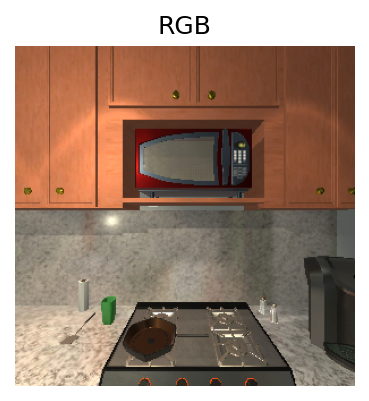

In [ ]:
plot_frames(controller.last_event)

# Visualizations

## Plot Frames

Visualize each frame and image modality available on an Event.

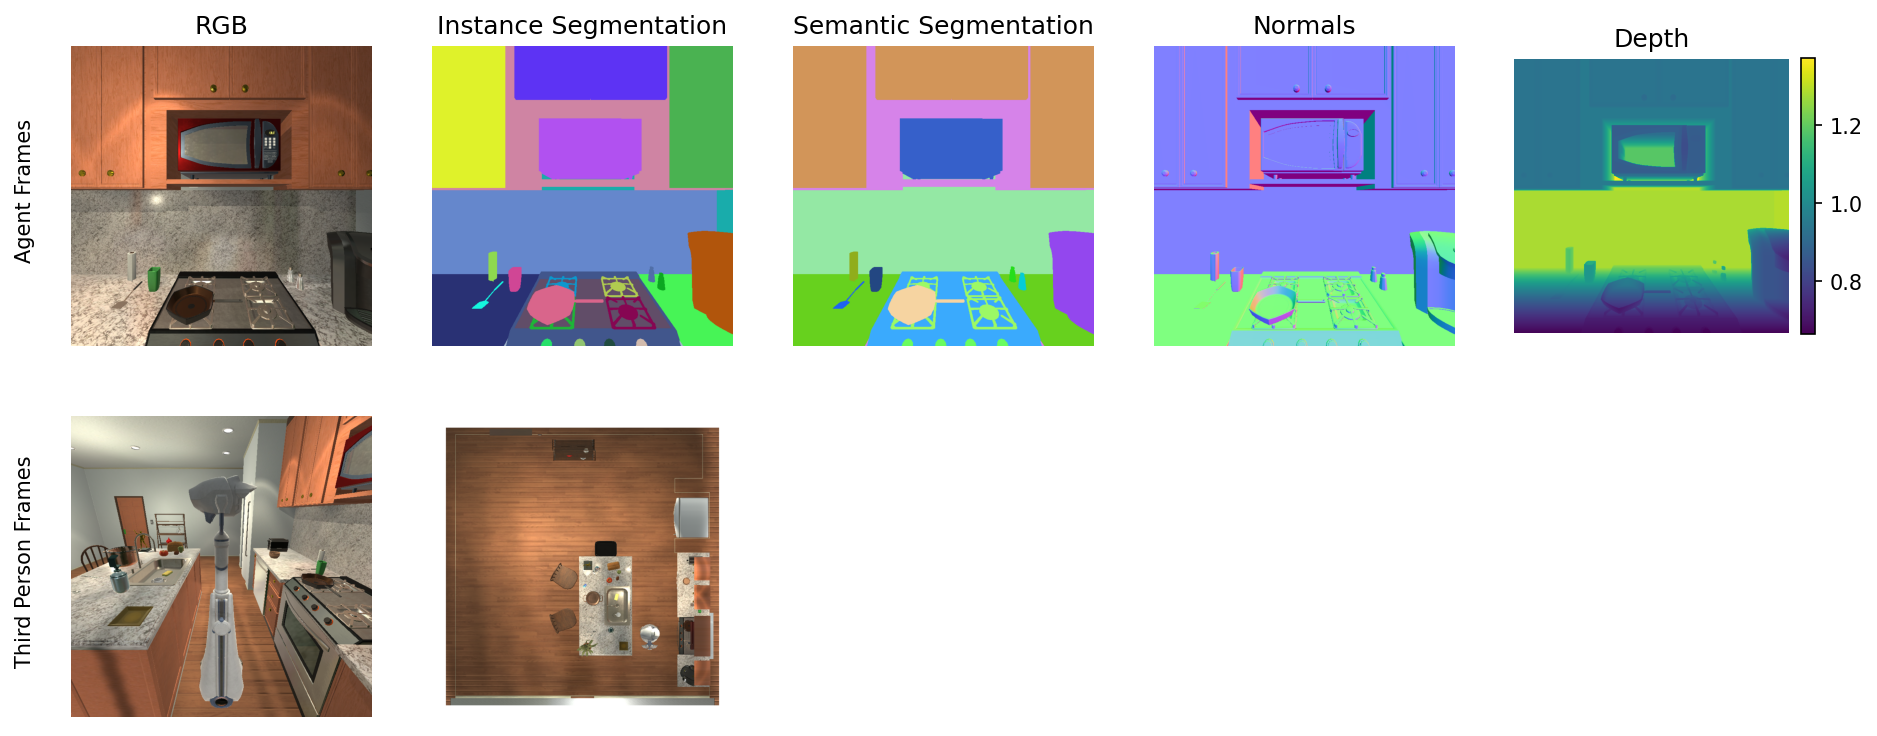

In [ ]:
renderDepthImage = True  #@param {type: "boolean"}
renderInstanceSegmentation = True  #@param {type: "boolean"}
renderSemanticSegmentation = True  #@param {type: "boolean"}
renderNormalsImage = True  #@param {type: "boolean"}

controller.reset(
    # makes the images a bit higher quality
    width=800,
    height=800,

    # Renders several new image modalities
    renderDepthImage=renderDepthImage,
    renderInstanceSegmentation=renderInstanceSegmentation,
    renderSemanticSegmentation=renderSemanticSegmentation,
    renderNormalsImage=renderNormalsImage
)

# adds a cameras from a third-person's point of view
scene_bounds = controller.last_event.metadata['sceneBounds']['center']
controller.step(
    action="AddThirdPartyCamera",
    position=dict(x=0, y=1.55, z=-2.3),
    rotation=dict(x=20, y=0, z=0)
)

# adds an orthographic top-down image
controller.step(
    action="AddThirdPartyCamera",
    position=dict(x=scene_bounds['x'], y=2.5, z=scene_bounds['z']),
    rotation=dict(x=90, y=0, z=0),
    orthographic=True,
    orthographicSize=3.25,
    skyboxColor="white"
)

plot_frames(controller.last_event)

## Show Objects Table

Filter, sort, and view metadata for each object in an Event. Note that we have left off `objectOrientedBoundingBox`, `axisAlignedBoundingBox`, and `receptacleObjectIds` because they are too big for the table.

In [ ]:
show_objects_table(controller.last_event.metadata['objects'])

Object Metadata. Not showing objectOrientedBoundingBox, axisAlignedBoundingBox, and receptacleObjectIds for clarity.


,objectType,objectId,name,position[x],position[y],position[z],rotation[x],rotation[y],rotation[z],distance,visible,obstructed,receptacle,toggleable,isToggled,breakable,isBroken,canFillWithLiquid,isFilledWithLiquid,dirtyable,isDirty,canBeUsedUp,isUsedUp,cookable,isCooked,ObjectTemperature,canChangeTempToHot,canChangeTempToCold,sliceable,isSliced,openable,isOpen,openness,pickupable,isPickedUp,moveable,mass,salientMaterials,parentReceptacles,isMoving
0,Floor,Floor|+00.00|+00.00|+00.00,Floor_b7d05094,0.0000,0.0000,0.0000,-0.0000,0.0000,0.0000,1.5409,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,False,False,0.0,False,False,False,1.0,[Wood],None,False
1,StoveBurner,StoveBurner|+00.84|+00.92|-01.10,StoveBurner_7e32c1bb,0.8420,0.9193,-1.0985,-0.0000,0.0000,0.0000,0.8557,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,True,False,False,False,False,False,0.0,False,False,False,0.0,None,None,False
2,Cabinet,Cabinet|+00.65|+00.48|+00.24,Cabinet_5bf34838,0.6488,0.4750,0.2450,-0.0000,270.0000,0.0000,1.6845,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,True,False,0.0,False,False,False,0.0,None,None,False
3,StoveBurner,StoveBurner|+01.08|+00.92|-01.50,StoveBurner_071647e1,1.0776,0.9193,-1.5042,-0.0000,0.0000,0.0000,1.1073,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,True,False,False,False,False,False,0.0,False,False,False,0.0,None,None,False
4,StoveBurner,StoveBurner|+00.84|+00.92|-01.50,StoveBurner_bd86687e,0.8420,0.9193,-1.5042,-0.0000,0.0000,0.0000,0.8797,True,False,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,True,False,False,False,False,False,0.0,False,False,False,0.0,None,None,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
62,Shelf,Shelf|-01.64|+00.88|+02.72,Shelf_f0e24e57,-1.6358,0.8809,2.7158,-0.0000,180.0223,0.0000,4.2899,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,False,False,0.0,False,False,False,0.0,None,None,False
63,ShelvingUnit,ShelvingUnit|-01.64|+00.01|+02.72,ShelvingUnit_90602e59,-1.6358,0.0068,2.7156,-0.0000,180.0223,0.0000,4.3819,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,False,False,0.0,False,False,True,22.0,[Wood],[Floor|+00.00|+00.00|+00.00],False
64,Chair,Chair|-01.83|+00.00|-00.03,Chair_82ba0433,-1.8320,0.0020,-0.0340,359.8598,119.9991,0.0290,2.3756,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,False,False,0.0,False,False,True,10.0,[Wood],[Floor|+00.00|+00.00|+00.00],False
65,Chair,Chair|-01.85|+00.00|-00.96,Chair_5332cfa8,-1.8540,0.0020,-0.9560,359.8597,67.8881,0.0288,2.0814,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,RoomTemp,False,False,False,False,False,False,0.0,False,False,True,10.0,[Wood],[Floor|+00.00|+00.00|+00.00],False


## Show Video

Builds a video from a sequence of image frames.

In [ ]:
controller.reset(
    width=500,
    height=500,
    renderDepthImage=False,
    renderNormalsImage=False,
    renderInstanceSegmentation=False,
    renderSemanticSegmentation=False
)
frames = [
    controller.step(action="RotateLeft", degrees=5).frame
    for _ in range(360 // 5)
]
show_video(frames, fps=5)

100%|██████████| 72/72 [00:00<00:00, 161.12it/s]


## Side By Side Frames

Shows 2 image frames side-by-side. This is often nice to visualize the before and after results from an action.

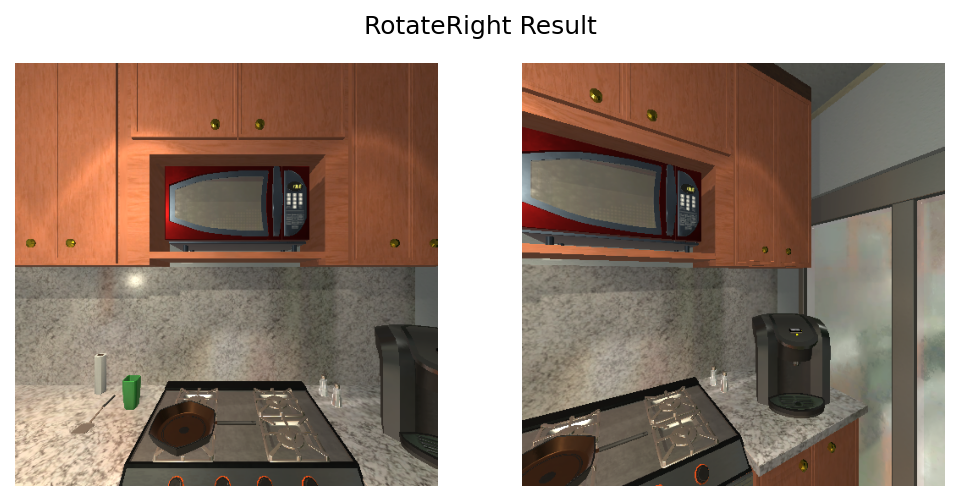

In [ ]:
side_by_side(
    frame1=controller.last_event.frame,
    frame2=controller.step("RotateRight", degrees=30).frame,
    title="RotateRight Result"
)

## Overlay Frames

Picking up Statue|-01.33|+00.92|+00.22


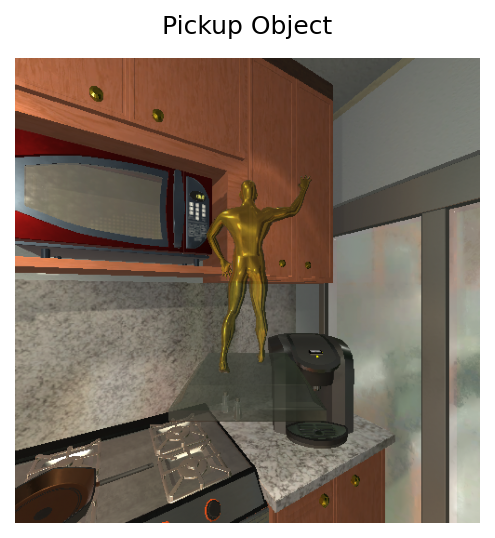

In [ ]:
objectId = next(obj["objectId"] for obj in controller.last_event.metadata['objects'] if obj['pickupable'])
print("Picking up " + objectId)

start_frame = controller.last_event.frame
pickup_frame = controller.step(
    action="PickupObject",
    objectId=objectId,
    forceAction=True
).frame

#@markdown `frame2_alpha` controls the opacity that the 2nd frame has, when blended over the 1st frame.
#@markdown Notice with a 0.75 opacity, the status's base appears see-throguh.

overlay(
    frame1=start_frame,
    frame2=pickup_frame,
    title="Pickup Object",
    frame2_alpha=0.75 #@param {type: "slider", min: 0.01, max: 0.99, step: 0.01}
)

In [17]:
import ai2thor.controller
controller = ai2thor.controller.Controller()

controller.reset('FloorPlan28')
controller.step(dict(action='Initialize', gridSize=0.25))

controller.step(dict(action='Teleport', x=-2.5, y=0.900998235, z=-3.0))
controller.step(dict(action='LookDown'))
event = controller.step(dict(action='Pass')) # Removed RotateRight to check default orientation
# In FloorPlan28, the agent should now be looking at a mug
mug_object_id = None
for o in event.metadata['objects']:
    if o['visible'] and o['pickupable'] and o['objectType'] == 'Mug':
        event = controller.step(dict(action='PickupObject', objectId=o['objectId']), raise_for_failure=True)
        # Explicitly check if the mug was successfully picked up and is in the inventory
        if any(inv_obj['objectId'] == o['objectId'] for inv_obj in event.metadata['inventoryObjects']):
            mug_object_id = o['objectId']
            print(f"Successfully picked up mug: {mug_object_id}")
        else:
            print(f"Failed to pick up mug: {o['objectId']}")
        break

if mug_object_id is None:
    raise RuntimeError("Mug not found or failed to pick up.")

# the agent now has the Mug in its inventory
# to put it into the Microwave, we need to open the microwave first

event = controller.step(dict(action='LookUp'))
event = controller.step(dict(action='RotateLeft'))

event = controller.step(dict(action='MoveLeft'))
event = controller.step(dict(action='MoveLeft'))
event = controller.step(dict(action='MoveLeft'))
event = controller.step(dict(action='MoveLeft'))

event = controller.step(dict(action='MoveAhead'))
event = controller.step(dict(action='MoveAhead'))
event = controller.step(dict(action='MoveAhead'))
event = controller.step(dict(action='MoveAhead'))
event = controller.step(dict(action='MoveAhead'))
event = controller.step(dict(action='MoveAhead'))

receptacle_object_id = None
for o in event.metadata['objects']:
    print(o['visible'],o['openable'],o['objectType'])
    if o['visible'] and o['openable'] and o['objectType'] == 'Microwave':
        event = controller.step(dict(action='OpenObject', objectId=o['objectId']), raise_for_failure=True)
        receptacle_object_id = o['objectId']
        break

if receptacle_object_id is None:
    raise RuntimeError("Microwave not found or not openable.")

event = controller.step(dict(
    action='PutObject',
    objectId=receptacle_object_id), raise_for_failure=True)

# close the microwave
event = controller.step(dict(
    action='CloseObject',
    objectId=receptacle_object_id), raise_for_failure=True)

Successfully picked up mug: Mug|-03.15|+00.82|-03.47
True False Apple
False True Blinds
False False Bowl
False False Bread
True False ButterKnife
False True Cabinet
True True Cabinet
False True Cabinet
False True Cabinet
True True Cabinet
True True Cabinet
True True Cabinet
False True Cabinet
False True Cabinet
False True Cabinet
False True Cabinet
False False CoffeeMachine
True False CounterTop
False False CounterTop
False False Cup
False False DiningTable
False False DiningTable
False False DishSponge
False True Drawer
False True Drawer
False True Drawer
False False Egg
False False Faucet
False False Floor
False False Fork
True True Fridge
False False GarbageCan
False False Knife
False False Lettuce
False False LightSwitch
True True Microwave


# Task
Summarize the overall conceptual framework and preliminary implementation strategy for automatically creating multi-agent, long-chain complex reasoning tasks, and point out potential directions for future research and development.

## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。


## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。

#### Instructions

一个“长链复杂推理任务”应包含以下核心组成部分：

1.  **整体任务目标 (Overall Task Goal)**：整个复杂推理任务的最终目标。
2.  **子目标 (Sub-Goals)**：为完成整体目标而需要实现的中间目标。
3.  **前置条件 (Preconditions)**：在特定子任务开始之前必须满足的条件。
4.  **后置条件 (Postconditions)**：特定子任务成功完成后所达到的状态或结果。
5.  **依赖关系 (Dependencies)**：子任务之间的关系，表明哪些子任务必须在其他子任务开始之前完成。
6.  **所需知识类型 (Required Knowledge Types)**：智能体可能需要具备的不同类别或领域的知识，以解决各种子任务（例如，常识知识、领域特定事实、程序性知识）。

评估生成任务复杂度的标准可以包括：

1.  **子目标的数量**：子目标越多，任务越复杂。
2.  **子任务之间依赖链的深度**：依赖关系链越长、越复杂，任务复杂度越高。
3.  **所需知识类型的多样性**：需要不同类型知识的任务通常更复杂。
4.  **涉及的智能体数量**：多智能体协作任务可能比单智能体任务更复杂。
5.  **潜在的冲突子目标或所需行动**：任务中存在需要解决的冲突或矛盾，会增加其复杂性。

## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。

#### Instructions

一个“长链复杂推理任务”应包含以下核心组成部分：

1.  **整体任务目标 (Overall Task Goal)**：整个复杂推理任务的最终目标。
2.  **子目标 (Sub-Goals)**：为完成整体目标而需要实现的中间目标。
3.  **前置条件 (Preconditions)**：在特定子任务开始之前必须满足的条件。
4.  **后置条件 (Postconditions)**：特定子任务成功完成后所达到的状态或结果。
5.  **依赖关系 (Dependencies)**：子任务之间的关系，表明哪些子任务必须在其他子任务开始之前完成。
6.  **所需知识类型 (Required Knowledge Types)**：智能体可能需要具备的不同类别或领域的知识，以解决各种子任务（例如，常识知识、领域特定事实、程序性知识）。

评估生成任务复杂度的标准可以包括：

1.  **子目标的数量**：子目标越多，任务越复杂。
2.  **子任务之间依赖链的深度**：依赖关系链越长、越复杂，任务复杂度越高。
3.  **所需知识类型的多样性**：需要不同类型知识的任务通常更复杂。
4.  **涉及的智能体数量**：多智能体协作任务可能比单智能体任务更复杂。
5.  **潜在的冲突子目标或所需行动**：任务中存在需要解决的冲突或矛盾，会增加其复杂性。

## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。

#### Instructions

一个“长链复杂推理任务”应包含以下核心组成部分：

1.  **整体任务目标 (Overall Task Goal)**：整个复杂推理任务的最终目标。
2.  **子目标 (Sub-Goals)**：为完成整体目标而需要实现的中间目标。
3.  **前置条件 (Preconditions)**：在特定子任务开始之前必须满足的条件。
4.  **后置条件 (Postconditions)**：特定子任务成功完成后所达到的状态或结果。
5.  **依赖关系 (Dependencies)**：子任务之间的关系，表明哪些子任务必须在其他子任务开始之前完成。
6.  **所需知识类型 (Required Knowledge Types)**：智能体可能需要具备的不同类别或领域的知识，以解决各种子任务（例如，常识知识、领域特定事实、程序性知识）。

评估生成任务复杂度的标准可以包括：

1.  **子目标的数量**：子目标越多，任务越复杂。
2.  **子任务之间依赖链的深度**：依赖关系链越长、越复杂，任务复杂度越高。
3.  **所需知识类型的多样性**：需要不同类型知识的任务通常更复杂。
4.  **涉及的智能体数量**：多智能体协作任务可能比单智能体任务更复杂。
5.  **潜在的冲突子目标或所需行动**：任务中存在需要解决的冲突或矛盾，会增加其复杂性。


## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。

#### Instructions

一个“长链复杂推理任务”应包含以下核心组成部分：

1.  **整体任务目标 (Overall Task Goal)**：整个复杂推理任务的最终目标。
2.  **子目标 (Sub-Goals)**：为完成整体目标而需要实现的中间目标。
3.  **前置条件 (Preconditions)**：在特定子任务开始之前必须满足的条件。
4.  **后置条件 (Postconditions)**：特定子任务成功完成后所达到的状态或结果。
5.  **依赖关系 (Dependencies)**：子任务之间的关系，表明哪些子任务必须在其他子任务开始之前完成。
6.  **所需知识类型 (Required Knowledge Types)**：智能体可能需要具备的不同类别或领域的知识，以解决各种子任务（例如，常识知识、领域特定事实、程序性知识）。

评估生成任务复杂度的标准可以包括：

1.  **子目标的数量**：子目标越多，任务越复杂。
2.  **子任务之间依赖链的深度**：依赖关系链越长、越复杂，任务复杂度越高。
3.  **所需知识类型的多样性**：需要不同类型知识的任务通常更复杂。
4.  **涉及的智能体数量**：多智能体协作任务可能比单智能体任务更复杂。
5.  **潜在的冲突子目标或所需行动**：任务中存在需要解决的冲突或矛盾，会增加其复杂性。


## 定义复杂推理任务的结构

### Subtask:
明确一个“长链复杂推理任务”应包含哪些组成部分，例如：任务目标、子目标、前置条件、后置条件、子任务之间的依赖关系、所需知识类型以及评估任务复杂度的标准。这将为任务的自动生成奠定基础。

#### Instructions

一个“长链复杂推理任务”应包含以下核心组成部分：

1.  **整体任务目标 (Overall Task Goal)**：整个复杂推理任务的最终目标。
2.  **子目标 (Sub-Goals)**：为完成整体目标而需要实现的中间目标。
3.  **前置条件 (Preconditions)**：在特定子任务开始之前必须满足的条件。
4.  **后置条件 (Postconditions)**：特定子任务成功完成后所达到的状态或结果。
5.  **依赖关系 (Dependencies)**：子任务之间的关系，表明哪些子任务必须在其他子任务开始之前完成。
6.  **所需知识类型 (Required Knowledge Types)**：智能体可能需要具备的不同类别或领域的知识，以解决各种子任务（例如，常识知识、领域特定事实、程序性知识）。

评估生成任务复杂度的标准可以包括：

1.  **子目标的数量**：子目标越多，任务越复杂。
2.  **子任务之间依赖链的深度**：依赖关系链越长、越复杂，任务复杂度越高。
3.  **所需知识类型的多样性**：需要不同类型知识的任务通常更复杂。
4.  **涉及的智能体数量**：多智能体协作任务可能比单智能体任务更复杂。
5.  **潜在的冲突子目标或所需行动**：任务中存在需要解决的冲突或矛盾，会增加其复杂性。



## 建模多智能体能力

### Subtask:
设计一种方式来表示和存储每个智能体的能力、技能集、知识领域以及它们之间的通信和协作机制。这将有助于算法在生成任务时，将合适的子任务分配给具备相应能力的智能体。


### 智能体能力模型设计

为了有效地表示和存储多智能体的能力、技能集、知识领域以及通信和协作机制，我们提出以下设计方案：

1.  **核心智能体属性**：
    *   **唯一标识符 (Agent ID)**：每个智能体都将拥有一个全局唯一的ID，用于在系统中进行识别。
    *   **智能体类型 (Agent Type)**：根据其主要功能或设计目的，智能体可以被分类为不同的类型，例如：
        *   `PerceptionAgent` (感知型智能体): 负责环境感知、数据采集和信息提取。
        *   `ManipulationAgent` (操作型智能体): 负责物理世界的动作执行，如移动、拾取、放置。
        *   `ReasoningAgent` (推理型智能体): 负责决策制定、问题解决、规划和学习。
        *   `CommunicationAgent` (通信型智能体): 负责智能体间的消息路由和协议管理。

2.  **能力与技能集 (Capabilities & Skill Sets)**：
    *   **表示方式**：使用一个列表或集合来存储智能体可以执行的具体动作（原子操作）或其擅长的领域。
    *   **示例**：
        *   **动作 (Actions)**: `["Move(x, y, z)", "PickUp(object_id)", "Place(object_id, target_location)", "Identify(object_type)", "ScanArea(radius)"]`
        *   **领域技能 (Domain Skills)**: `["ImageRecognition", "NaturalLanguageUnderstanding", "PathPlanning", "ReinforcementLearning", "MechanicalAssembly"]`
    *   **实现**：每个能力或技能可以关联一个预定义的函数或模块，智能体通过调用这些函数来执行相应的功能。

3.  **知识领域 (Knowledge Domains)**：
    *   **表示方式**：使用关键词、标签或本体（ontologies）来描述智能体可以访问、理解或处理的信息类型。
    *   **示例**：`["PhysicsLaws", "ChemistryReactions", "HistoricalEvents", "LogisticsRules", "MedicalDiagnosisCriteria", "EnvironmentalRegulations"]`
    *   **实现**：知识领域可以链接到特定的知识库、数据库或内部的知识表示模型（如语义网络、逻辑规则集）。

4.  **通信机制 (Communication Mechanisms)**：
    *   **交换方式**：
        *   **消息传递 (Message Passing)**：智能体通过发送和接收结构化消息进行通信。消息可以包含指令、数据请求、状态更新等。
        *   **共享内存/黑板 (Shared Memory/Blackboard)**：智能体通过读写一个共享的数据空间来交换信息，适用于紧耦合系统。
        *   **发布/订阅 (Publish/Subscribe)**：智能体可以发布特定主题的信息，其他订阅了该主题的智能体可以接收到信息，实现解耦通信。
    *   **内容格式**：定义统一的消息协议和数据格式，例如JSON、XML或自定义二进制协议，以确保互操作性。
    *   **实现**：可以构建一个中央消息代理（Message Broker）或使用分布式通信框架（如ROS、gRPC）。

5.  **协作机制 (Collaboration Mechanisms)**：
    *   **任务分解与分配 (Task Decomposition and Allocation)**：
        *   **设计**：复杂任务被分解为更小的子任务，然后根据智能体的能力和可用资源，将子任务分配给最合适的智能体。
        *   **实现**：可以通过拍卖机制、协商、集中式调度器或分布式规划算法来完成。
    *   **结果集成 (Result Integration)**：
        *   **设计**：当多个智能体完成其子任务后，它们的结果需要被收集、合并和验证，以形成最终的整体解决方案。
        *   **实现**：可以由一个协调智能体负责，或者通过数据融合技术自动进行。
    *   **冲突解决 (Conflict Resolution)**：
        *   **设计**：当智能体之间发生资源争夺、行动冲突或目标不一致时，需要有机制来解决这些冲突，以确保系统稳定运行。
        *   **实现**：可以通过优先级、协商协议、回溯或预定义的冲突解决策略来管理。

## 开发任务生成算法

### Subtask:
设计一个算法，能够根据定义的任务结构和智能体能力，自动组合和构建新的、具有复杂逻辑链条的任务。这可能涉及到使用规划技术、规则引擎，甚至利用大型语言模型（LLM）来生成任务描述和内在逻辑。


### 1. 任务生成算法的核心组件

为了设计一个能够根据定义的任务结构和智能体能力，自动组合和构建新的、具有复杂逻辑链条的任务的算法，我们需要识别以下核心组件：

*   **任务目标选择器 (Task Objective Selector)**：负责选择或生成整体任务目标。
*   **子任务分解器 (Subtask Decomposer)**：将整体任务目标分解为更小、可执行的子任务。
*   **依赖关系构建器 (Dependency Builder)**：建立子任务之间的逻辑依赖关系。
*   **智能体分配器 (Agent Allocator)**：将子任务分配给合适的智能体。

### 2. 任务目标选择器 (Task Objective Selector) 的功能

任务目标选择器是任务生成算法的起始点，其核心功能是确定或生成一个高级别的、整体性的任务目标。这个组件可以采用以下两种主要方式来运作：

1.  **从预定义目标库中选择**：系统维护一个包含多种预设任务目标的库。这些目标可以是通用的（例如“清洁房间”、“准备食物”）或特定领域相关的。选择器可以根据外部输入（如用户请求）、环境状态或随机策略，从该库中挑选一个目标。
2.  **基于参数生成新目标**：对于更复杂或动态的场景，任务目标选择器可以利用一套参数（例如，特定对象、地点、状态改变要求等）来动态构造一个全新的任务目标。这可能涉及到组合不同的概念，例如，“将'脏盘子'放到'洗碗机'中”，其中“脏盘子”和“洗碗机”都是可变的参数。

**整合LLM的能力**：

*   **生成自然语言描述**：利用大型语言模型（LLM）根据选定或生成的任务目标，生成自然、清晰的任务描述，使其更易于人类理解或作为其他组件（如子任务分解器）的输入。
*   **目标验证与细化**：LLM可以被用于验证生成的目标是否合理、可实现，并提供细化的建议，确保目标与当前环境和智能体能力相符。
*   **情境化目标生成**：根据当前环境的感知信息（例如，感知到“客厅很乱”），LLM可以直接生成一个相应的任务目标（“清理客厅”）。

### 3. 子任务分解器 (Subtask Decomposer) 的逻辑

子任务分解器是任务生成算法的核心之一，它负责将由“任务目标选择器”确定的高级别、整体性任务目标，递归地拆解成一系列更小、更具体的、可由智能体直接执行的原子或近原子级子任务。

**分解策略**：

1.  **基于领域知识和预设规则**：
    *   **规则库**：维护一个包含任务分解规则的知识库。例如，如果目标是“清洁房间”，规则可以定义为“清洁房间” = “整理物品” + “清扫地面” + “擦拭表面”。每个子任务又可以进一步分解。
    *   **状态前置/后置条件**：利用对环境状态变化的理解来指导分解。例如，要“烧水”，可能需要“找到水壶” -> “加水” -> “放置在炉子上” -> “启动炉子”。
    *   **任务模板**：为常见的任务类型创建预定义的分解模板，其中包含步骤序列和决策点。

2.  **递归分解**：分解过程通常是递归的。一个复杂的任务被分解为几个中级子任务，每个中级子任务又可能被进一步分解，直到所有子任务都足够简单，可以直接映射到智能体的基本操作或能力。

3.  **考虑智能体能力**：在分解过程中，子任务分解器需要考虑智能体的现有能力。如果某个子任务无法被当前任何智能体的原子操作直接执行，就需要将其进一步分解，直到达到智能体可操作的粒度。

**整合LLM的能力**：

*   **零/少样本分解 (Zero/Few-shot Decomposition)**：
    *   **理解意图**：LLM可以理解复杂任务目标的自然语言描述，并根据其训练数据中包含的常识和任务知识，生成初步的子任务序列。
    *   **动态分解**：当遇到不在预设规则库中的新任务时，LLM可以尝试根据上下文和有限的示例（少样本）或完全没有示例（零样本）来推断合理的分解路径。
    *   **处理模糊性**：LLM能够处理任务描述中的模糊性，并根据环境信息提供更具体的分解建议。
*   **生成详细子任务描述**：LLM不仅可以生成子任务的列表，还可以为每个子任务提供详细的自然语言描述，包括其目标、期望结果以及可能的执行方式，这有助于智能体理解和执行。
*   **验证分解合理性**：LLM可以评估分解后的子任务序列是否逻辑连贯、完整，并能够达成原始任务目标。它可以识别缺失的步骤或不合理的顺序。
*   **条件分支与异常处理**：LLM可以辅助生成包含条件判断的子任务，例如“如果物体A存在则执行X，否则执行Y”，甚至提供简单的异常处理建议。

### 4. 依赖关系构建器 (Dependency Builder) 的实现方法

依赖关系构建器负责在子任务分解器生成的一系列子任务之间，建立正确的逻辑关系，确保任务执行的顺序性、并行性以及条件性，从而保证整个任务流的连贯性和正确性。这是构建复杂逻辑链条任务的关键。

**实现方法**：

1.  **基于前置条件 (Pre-conditions) 和后置条件 (Post-conditions)**：
    *   **定义**：每个原子或近原子级子任务都应有明确定义的前置条件（该子任务执行前必须满足的状态）和后置条件（该子任务执行后会改变的环境状态）。
    *   **构建逻辑**：依赖关系构建器通过比较子任务的后置条件和下一个子任务的前置条件来自动建立依赖。如果子任务A的后置条件满足了子任务B的前置条件，那么A就成为B的一个直接前驱。
    *   **例子**：子任务“拿起杯子”的后置条件可能是“手中持有杯子”，而子任务“往杯子倒水”的前置条件是“手中持有杯子”。因此，这两个子任务之间存在顺序依赖。

2.  **依赖类型**：
    *   **顺序依赖 (Sequential Dependency)**：一个子任务必须在另一个子任务完成之后才能开始。这是最常见的依赖类型。
    *   **并行依赖 (Parallel Dependency)**：两个或多个子任务可以同时执行，因为它们之间没有直接的输入/输出关系，或者它们的操作不互相干扰。
    *   **条件依赖 (Conditional Dependency)**：某个子任务的执行取决于特定条件的满足，该条件可能由其他子任务的输出或环境状态决定。例如，“如果检测到脏污，则执行清洁子任务”。

3.  **图结构表示**：
    *   **任务图 (Task Graph)**：将子任务和它们之间的依赖关系表示为一个有向图（通常是DAG，有向无环图）。图中的节点是子任务，边表示依赖关系的方向。
    *   **拓扑排序**：一旦构建了任务图，可以使用拓扑排序等算法来确定可能的执行顺序，并识别并行执行的机会。

**整合LLM的能力**：

*   **自动推断复杂依赖**：LLM可以被训练来理解子任务的自然语言描述，并根据其内在的语义和常识，推断出更复杂的、非显式的依赖关系。例如，它可能知道“打开冰箱”通常是“取食物”的前置。
*   **生成依赖关系图**：LLM可以根据子任务列表及其描述，直接生成一个表示依赖关系的结构化输出（例如，JSON格式），该输出可以被程序解析并用于构建任务图。
*   **识别缺失或冲突的依赖**：LLM能够审查生成的依赖关系，识别出可能导致逻辑不连贯、死锁或无限循环的缺失依赖或冲突依赖，并提出修正建议。
*   **优化任务流**：在考虑智能体能力和资源的前提下，LLM可以建议调整依赖关系，以优化任务的执行效率（例如，通过最大化并行性）。
*   **处理不确定性**：对于涉及不确定环境的依赖，LLM可以生成包含条件分支和回滚策略的更鲁棒的依赖结构，以应对执行过程中的意外情况。

```markdown
### 5. 智能体分配器 (Agent Allocator) 的策略

智能体分配器是任务生成算法的最终环节之一，它负责将“子任务分解器”分解出的原子或近原子级子任务，根据“依赖关系构建器”确定的逻辑顺序，智能地分配给最合适的智能体。这不仅需要考虑单个智能体的能力，还需要考虑多智能体协作、资源利用和通信效率。

**分配策略**：

1.  **基于能力匹配 (Capability Matching)**：
    *   **能力描述**：每个智能体都应有一个明确的能力集描述，列出其可以执行的操作、感知的传感器类型、可以交互的物体类型等。
    *   **任务需求匹配**：智能体分配器会将每个子任务的需求（例如，“需要操作一个杯子”，“需要移动到一个特定位置”，“需要识别一个物体”）与智能体的能力集进行匹配。只有具备执行该子任务所需所有能力的智能体才能被列为候选。

2.  **基于资源可用性 (Resource Availability)**：
    *   **资源状态**：考虑智能体的当前状态，例如电池电量、负载能力、当前位置、工具是否被占用等。一个智能体可能具备执行某个任务的能力，但由于资源限制（例如，已携带一个物体，无法再拿起另一个），它可能不是最佳选择。
    *   **环境资源**：评估任务所需的物理资源（如特定工具、空间）是否可被分配的智能体获取。

3.  **负载平衡 (Load Balancing)**：
    *   在多个智能体都能够执行同一个子任务的情况下，分配器会考虑所有智能体的当前工作负载，将任务分配给负载较轻的智能体，以优化整体任务执行效率。

4.  **协作与通信开销 (Collaboration and Communication Overhead)**：
    *   **团队协作**：如果一个复杂的子任务需要多个智能体协作完成，分配器应能识别这种需求，并分配能够有效协同工作的智能体。这可能涉及到智能体之间的距离、通信能力以及相互协作的历史数据。
    *   **最小化通信**：尽量将逻辑上紧密关联的子任务分配给同一个智能体或物理位置相近的智能体，以减少通信延迟和数据传输开销。

5.  **优先级与时效性 (Priority and Timeliness)**：
    *   根据子任务的优先级或是否有时间限制，分配器会优先将高优先级或即将到期的任务分配给有能力的智能体。

**整合LLM的能力**：

*   **智能体能力理解与匹配**：LLM可以更灵活地理解智能体的自然语言能力描述，并将其与子任务的自然语言需求进行匹配，而不仅仅是基于硬编码的规则。这使得能力匹配更具泛化性。
*   **情境感知分配**：LLM可以综合考虑智能体的能力、当前环境状态、资源可用性以及历史数据，进行更精细的情境感知分配。例如，如果一个智能体刚刚完成一个位于厨房的任务，而下一个任务也在厨房，LLM可能会倾向于将任务分配给它。
*   **多智能体协调策略生成**：对于需要多智能体协作的任务，LLM可以生成协作计划，包括哪个智能体执行哪个部分，如何进行交接和通信，以及如何处理潜在的冲突。
*   **优化与冲突解决**：LLM可以评估多种分配方案，预测潜在的瓶颈或冲突，并提出优化建议，例如，调整分配以提高并行度或避免资源争抢。
*   **可解释性**：LLM不仅可以做出分配决策，还可以解释其决策背后的理由，这对于调试和优化任务生成算法非常有用。
```

### 5. 智能体分配器 (Agent Allocator) 的策略

智能体分配器是任务生成算法的最终环节之一，它负责将“子任务分解器”分解出的原子或近原子级子任务，根据“依赖关系构建器”确定的逻辑顺序，智能地分配给最合适的智能体。这不仅需要考虑单个智能体的能力，还需要考虑多智能体协作、资源利用和通信效率。

**分配策略**：

1.  **基于能力匹配 (Capability Matching)**：
    *   **能力描述**：每个智能体都应有一个明确的能力集描述，列出其可以执行的操作、感知的传感器类型、可以交互的物体类型等。
    *   **任务需求匹配**：智能体分配器会将每个子任务的需求（例如，“需要操作一个杯子”，“需要移动到一个特定位置”，“需要识别一个物体”）与智能体的能力集进行匹配。只有具备执行该子任务所需所有能力的智能体才能被列为候选。

2.  **基于资源可用性 (Resource Availability)**：
    *   **资源状态**：考虑智能体的当前状态，例如电池电量、负载能力、当前位置、工具是否被占用等。一个智能体可能具备执行某个任务的能力，但由于资源限制（例如，已携带一个物体，无法再拿起另一个），它可能不是最佳选择。
    *   **环境资源**：评估任务所需的物理资源（如特定工具、空间）是否可被分配的智能体获取。

3.  **负载平衡 (Load Balancing)**：
    *   在多个智能体都能够执行同一个子任务的情况下，分配器会考虑所有智能体的当前工作负载，将任务分配给负载较轻的智能体，以优化整体任务执行效率。

4.  **协作与通信开销 (Collaboration and Communication Overhead)**：
    *   **团队协作**：如果一个复杂的子任务需要多个智能体协作完成，分配器应能识别这种需求，并分配能够有效协同工作的智能体。这可能涉及到智能体之间的距离、通信能力以及相互协作的历史数据。
    *   **最小化通信**：尽量将逻辑上紧密关联的子任务分配给同一个智能体或物理位置相近的智能体，以减少通信延迟和数据传输开销。

5.  **优先级与时效性 (Priority and Timeliness)**：
    *   根据子任务的优先级或是否有时间限制，分配器会优先将高优先级或即将到期的任务分配给有能力的智能体。

**整合LLM的能力**：

*   **智能体能力理解与匹配**：LLM可以更灵活地理解智能体的自然语言能力描述，并将其与子任务的自然语言需求进行匹配，而不仅仅是基于硬编码的规则。这使得能力匹配更具泛化性。
*   **情境感知分配**：LLM可以综合考虑智能体的能力、当前环境状态、资源可用性以及历史数据，进行更精细的情境感知分配。例如，如果一个智能体刚刚完成一个位于厨房的任务，而下一个任务也在厨房，LLM可能会倾向于将任务分配给它。
*   **多智能体协调策略生成**：对于需要多智能体协作的任务，LLM可以生成协作计划，包括哪个智能体执行哪个部分，如何进行交接和通信，以及如何处理潜在的冲突。
*   **优化与冲突解决**：LLM可以评估多种分配方案，预测潜在的瓶颈或冲突，并提出优化建议，例如，调整分配以提高并行度或避免资源争抢。
*   **可解释性**：LLM不仅可以做出分配决策，还可以解释其决策背后的理由，这对于调试和优化任务生成算法非常有用。

### 6. 整合规划技术、规则引擎和大型语言模型 (LLM)

为了辅助或驱动上述任务生成算法组件的实现，特别是用于生成任务描述和验证逻辑一致性，我们可以有效地整合规划技术、规则引擎和大型语言模型（LLM）。

**1. 规划技术 (Planning Techniques)**：

*   **STRIPS (STanford Research Institute Problem Solver) / PDDL (Planning Domain Definition Language)**：
    *   **整合点**：STRIPS或基于PDDL的规划器可以作为“子任务分解器”和“依赖关系构建器”的核心。我们可以为智能体的基本行动定义操作符（operators），每个操作符包含前置条件（preconditions）和后置效果（effects）。规划器可以根据初始状态和目标状态，自动生成一系列满足依赖关系的动作序列（即子任务序列）。
    *   **优势**：确保生成的任务序列在逻辑上是可行的，并且能够达成目标状态，具有很强的形式化验证能力。
    *   **局限性**：需要精确定义领域模型、操作符和状态。对动态和不确定环境的适应性较差，难以处理模糊或未知的任务。

*   **分层任务网络 (Hierarchical Task Network, HTN) 规划**：
    *   **整合点**：HTN规划与“子任务分解器”的概念高度契合。它允许将复杂任务分解为更小的任务，并递归地应用分解方法，直到所有任务都变为可执行的基本操作。HTN规划器可以直接编码领域知识和分解规则。
    *   **优势**：能够处理更复杂、更有结构的任务，通过预定义的方法（methods）来指导分解，避免了盲目搜索，效率更高。
    *   **局限性**：依赖于人工定义的任务分解方法，当任务类型发生变化时，需要人工更新HTN模型。

**2. 规则引擎 (Rule Engines)**：

*   **整合点**：规则引擎可以作为“任务目标选择器”、“子任务分解器”和“智能体分配器”的补充或核心决策机制。例如，可以定义规则“如果环境温度过高，则目标为'开启空调'”，或“如果智能体A具有搬运能力且空闲，则将其分配给搬运任务”。
*   **优势**：直观、易于理解和维护，可以灵活地处理各种条件逻辑和业务规则。适合处理明确、结构化的决策场景。
*   **局限性**：规则数量增多时，管理复杂性增加；难以处理模糊或需要推理的决策；不具备生成新的、未预见的任务或逻辑的能力。

**3. 大型语言模型 (LLM)**：

*   **整合点**：LLM可以贯穿任务生成算法的各个阶段，提供更高级别的语义理解、生成能力和泛化能力。
    *   **任务目标选择器**：根据自然语言输入或环境感知，LLM可以生成符合语义和上下文的任务目标。
    *   **子任务分解器**：利用其零/少样本学习能力，LLM可以直接从高级任务目标生成详细的子任务序列，甚至包括条件分支，无需预定义所有规则。
    *   **依赖关系构建器**：LLM能够理解子任务的语义关系，自动推断出前置/后置条件，并构建复杂的逻辑依赖图，识别潜在的冲突或缺失。
    *   **智能体分配器**：LLM可以综合考虑智能体的自然语言能力描述、当前状态、历史表现和情境信息，做出更智能、更具解释性的分配决策，甚至生成多智能体协作计划。
    *   **任务描述生成**：LLM能够为生成的整个任务和每个子任务提供清晰、连贯的自然语言描述，极大地增强了可读性和可解释性。
    *   **逻辑一致性验证**：LLM可以对生成的任务序列和依赖关系进行语义层面的检查，识别逻辑上的不合理之处或潜在的执行问题，并提出修正建议。
*   **优势**：强大的泛化能力和语义理解能力，可以处理非结构化信息和模糊指令，实现更灵活、更智能的任务生成。能够生成新颖的任务描述和逻辑。
*   **局限性**：输出可能存在幻觉、不确定性或不准确性，需要结合形式化方法进行验证；计算成本较高；对提示工程（Prompt Engineering）有较高要求。

**总结**：

理想的任务生成算法会采取混合方法，即以**规划技术**和**规则引擎**提供坚实的逻辑骨架和可验证性，同时利用**LLM**的强大生成和理解能力，来弥补前者的局限性，特别是在处理自然语言、生成多样化任务描述和进行高级语义推理方面。LLM可以作为一个强大的“辅助大脑”，在规划器的约束下，填充细节、生成变体、提供情境化洞察，并验证整体逻辑的合理性。

## 实现任务创建原型模块

### Subtask:
编写Python代码，实现一个概念验证（Proof-of-Concept）模块，能够在特定且受限的领域内，生成一个简单的多智能体、长链推理任务实例。这将侧重于展示核心的任务生成逻辑。


**Reasoning**:
First, I will set up the specific domain (a kitchen environment) and define the overall task goal (making coffee). Then, I will define two virtual agents, 'CoffeeMasterBot' and 'CleanerBot', along with their respective capabilities and knowledge domains. This addresses instructions 1 and 2 of the subtask.



In [24]:
import json

# 1. Define a simple, specific domain and an overall task goal.
DOMAIN = "Home Kitchen Environment"
OVERALL_TASK_GOAL = "Make a cup of coffee"

# 2. Define at least two virtual agents and their capabilities/knowledge.
AGENTS = {
    "CoffeeMasterBot": {
        "capabilities": [
            "take_coffee_beans",
            "grind_coffee_beans",
            "prepare_coffee_machine",
            "brew_coffee",
            "pour_coffee",
            "clean_coffee_machine_parts"
        ],
        "knowledge": ["coffee_types", "brewing_methods", "machine_maintenance"]
    },
    "CleanerBot": {
        "capabilities": [
            "clean_countertop",
            "clean_spills",
            "empty_trash"
        ],
        "knowledge": ["cleaning_supplies", "hygiene_standards"]
    }
}

print("Domain, overall task goal, and agents with capabilities defined.")

Domain, overall task goal, and agents with capabilities defined.


**Reasoning**:
Next, I will implement a simplified 'Task Objective Selector' by directly using the predefined 'OVERALL_TASK_GOAL'. This fulfills instruction 3 of the subtask.



In [19]:
TASK_OBJECTIVE = OVERALL_TASK_GOAL
print(f"Task Objective Selector set overall task goal: {TASK_OBJECTIVE}")

Task Objective Selector set overall task goal: Make a cup of coffee


**Reasoning**:
Now, I will implement a simplified 'Subtask Decomposer' by manually breaking down the 'Make a cup of coffee' objective into a sequence of atomic subtasks. Each subtask will have explicitly defined pre-conditions and post-conditions, addressing instruction 4 of the subtask.



In [20]:
SUBTASKS = {
    "subtask_1": {
        "description": "Take coffee beans from storage",
        "pre_conditions": ["coffee_beans_available", "coffee_beans_in_storage"],
        "post_conditions": ["coffee_beans_in_hand"]
    },
    "subtask_2": {
        "description": "Grind coffee beans",
        "pre_conditions": ["coffee_beans_in_hand", "grinder_available"],
        "post_conditions": ["ground_coffee_available"]
    },
    "subtask_3": {
        "description": "Prepare coffee machine",
        "pre_conditions": ["coffee_machine_available", "water_available"],
        "post_conditions": ["coffee_machine_ready"]
    },
    "subtask_4": {
        "description": "Brew coffee",
        "pre_conditions": ["ground_coffee_available", "coffee_machine_ready"],
        "post_conditions": ["brewed_coffee_in_machine", "used_coffee_grounds"]
    },
    "subtask_5": {
        "description": "Pour coffee into cup",
        "pre_conditions": ["brewed_coffee_in_machine", "cup_available"],
        "post_conditions": ["coffee_in_cup"]
    },
    "subtask_6": {
        "description": "Clean coffee machine parts",
        "pre_conditions": ["used_coffee_grounds"],
        "post_conditions": ["coffee_machine_parts_clean"]
    },
    "subtask_7": {
        "description": "Clean countertop from spills",
        "pre_conditions": ["spills_on_countertop"],
        "post_conditions": ["countertop_clean"]
    }
}

print("Subtasks defined with pre-conditions and post-conditions.")

Subtasks defined with pre-conditions and post-conditions.


**Reasoning**:
Next, I will implement a simplified 'Dependency Builder' based on the pre-conditions and post-conditions defined for each subtask. This will identify which subtasks must be completed before others, fulfilling instruction 5 of the subtask.



In [21]:
DEPENDENCIES = {}

# Iterate through each subtask to determine its dependencies
for task_id, task_details in SUBTASKS.items():
    DEPENDENCIES[task_id] = []
    current_pre_conditions = set(task_details["pre_conditions"])

    # Compare with post-conditions of other subtasks
    for other_task_id, other_task_details in SUBTASKS.items():
        if task_id == other_task_id:
            continue

        other_post_conditions = set(other_task_details["post_conditions"])

        # If any post-condition of 'other_task_id' is a pre-condition for 'task_id',
        # then 'task_id' depends on 'other_task_id'.
        if current_pre_conditions.intersection(other_post_conditions):
            DEPENDENCIES[task_id].append(other_task_id)

    # Sort dependencies for consistent output
    DEPENDENCIES[task_id].sort()

print("Subtask dependencies built based on pre-conditions and post-conditions.")
print(json.dumps(DEPENDENCIES, indent=4))

Subtask dependencies built based on pre-conditions and post-conditions.
{
    "subtask_1": [],
    "subtask_2": [
        "subtask_1"
    ],
    "subtask_3": [],
    "subtask_4": [
        "subtask_2",
        "subtask_3"
    ],
    "subtask_5": [
        "subtask_4"
    ],
    "subtask_6": [
        "subtask_4"
    ],
    "subtask_7": []
}


**Reasoning**:
Now, I will implement a simplified 'Agent Allocator' that assigns each subtask to the most suitable virtual agent based on its capabilities, fulfilling instruction 6 of the subtask.



In [22]:
AGENT_ALLOCATIONS = {}

for task_id, task_details in SUBTASKS.items():
    assigned_agent = None
    task_description = task_details["description"].lower()

    # Simple keyword-based matching for capabilities
    if "coffee" in task_description or "brew" in task_description or "grind" in task_description or "pour" in task_description:
        if "coffeemasterbot" in AGENTS and any(cap in task_description for cap in AGENTS["CoffeeMasterBot"]["capabilities"]):
            assigned_agent = "CoffeeMasterBot"
        # Refined check for specific coffee tasks
        if "take coffee beans" in task_description and "take_coffee_beans" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"
        elif "grind coffee beans" in task_description and "grind_coffee_beans" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"
        elif "prepare coffee machine" in task_description and "prepare_coffee_machine" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"
        elif "brew coffee" in task_description and "brew_coffee" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"
        elif "pour coffee" in task_description and "pour_coffee" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"
        elif "clean coffee machine parts" in task_description and "clean_coffee_machine_parts" in AGENTS["CoffeeMasterBot"]["capabilities"]:
            assigned_agent = "CoffeeMasterBot"

    elif "clean" in task_description or "spills" in task_description or "empty" in task_description:
        if "cleanerbot" in AGENTS and any(cap in task_description for cap in AGENTS["CleanerBot"]["capabilities"]):
            assigned_agent = "CleanerBot"
        # Refined check for specific cleaning tasks
        if "clean countertop" in task_description and "clean_countertop" in AGENTS["CleanerBot"]["capabilities"]:
            assigned_agent = "CleanerBot"
        elif "clean spills" in task_description and "clean_spills" in AGENTS["CleanerBot"]["capabilities"]:
            assigned_agent = "CleanerBot"

    AGENT_ALLOCATIONS[task_id] = assigned_agent

print("Subtasks assigned to agents:")
print(json.dumps(AGENT_ALLOCATIONS, indent=4))


Subtasks assigned to agents:
{
    "subtask_1": "CoffeeMasterBot",
    "subtask_2": "CoffeeMasterBot",
    "subtask_3": "CoffeeMasterBot",
    "subtask_4": "CoffeeMasterBot",
    "subtask_5": "CoffeeMasterBot",
    "subtask_6": "CoffeeMasterBot",
    "subtask_7": "CleanerBot"
}


**Reasoning**:
I will now combine all the generated components (overall goal, subtasks, dependencies, and agent allocations) into a single structured dictionary and output it as a JSON string. This fulfills instruction 7 of the subtask.



In [23]:
overall_task_structure = {
    "overall_goal": TASK_OBJECTIVE,
    "domain": DOMAIN,
    "agents": AGENTS,
    "subtasks": SUBTASKS,
    "dependencies": DEPENDENCIES,
    "agent_allocations": AGENT_ALLOCATIONS
}

print("Generated Overall Task Structure:")
print(json.dumps(overall_task_structure, indent=4))


Generated Overall Task Structure:
{
    "overall_goal": "Make a cup of coffee",
    "domain": "Home Kitchen Environment",
    "agents": {
        "CoffeeMasterBot": {
            "capabilities": [
                "take_coffee_beans",
                "grind_coffee_beans",
                "prepare_coffee_machine",
                "brew_coffee",
                "pour_coffee",
                "clean_coffee_machine_parts"
            ],
            "knowledge": [
                "coffee_types",
                "brewing_methods",
                "machine_maintenance"
            ]
        },
        "CleanerBot": {
            "capabilities": [
                "clean_countertop",
                "clean_spills",
                "empty_trash"
            ],
            "knowledge": [
                "cleaning_supplies",
                "hygiene_standards"
            ]
        }
    },
    "subtasks": {
        "subtask_1": {
            "description": "Take coffee beans from storage",
       

## 定义任务评估与验证方法

### Subtask:
建立一套评估标准和方法，以验证所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，并确保任务是可解且有意义的。这可能包括模拟智能体执行任务或通过人工评估。


### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。


### 1. 明确定义评估“复杂性”、“长链”和“多智能体”任务的具体标准和指标

为了量化和评估所生成的任务是否确实具有“复杂性”、“长链”和“多智能体”的特点，我们可以定义以下具体标准和指标：

**A. 复杂性 (Complexity) 评估指标**：
*   **子任务数量 (Number of Subtasks)**：任务分解后，原子或近原子级子任务的总量。数量越多，复杂性越高。
*   **决策点数量 (Number of Decision Points)**：任务执行过程中，需要智能体根据环境状态或条件做出选择的次数。决策点越多，复杂性越高。
*   **环境状态维度 (Environmental State Dimension)**：任务所涉及的环境状态变量的数量和种类。状态空间越大，任务推理难度越大。
*   **不确定性程度 (Degree of Uncertainty)**：任务中环境信息或行动结果的不确定性程度。不确定性越高，复杂性越高。
*   **所需知识类型多样性 (Diversity of Required Knowledge Types)**：智能体需要调用的不同领域知识（例如，物理、化学、社会常识）的种类。多样性越高，复杂性越高。

**B. 长链 (Long-Chain) 评估指标**：
*   **最长依赖链深度 (Depth of Longest Dependency Chain)**：任务图中从起始节点到任何终止节点的最长路径长度。链条越长，任务的“长链”特性越显著。
*   **平均依赖链深度 (Average Dependency Chain Depth)**：所有子任务到其最终目标所需的平均依赖步骤数。
*   **任务图的连通性 (Connectivity of Task Graph)**：任务图中边的密度，指示子任务之间相互依赖的程度。高度连通可能意味着更紧密的序列。
*   **前置/后置条件覆盖率 (Pre/Post-condition Coverage)**：成功链接子任务所需的前置条件有多少被其他子任务的后置条件满足。高覆盖率表明任务链的完整性。

**C. 多智能体 (Multi-Agent) 评估指标**：
*   **涉及智能体数量 (Number of Involved Agents)**：完成任务所需的不同智能体的最小数量。
*   **协作强度 (Collaboration Intensity)**：需要多个智能体共同完成单个子任务或在同一时间段内协调行动的次数。例如，智能体之间需要数据交换或物理协同的频率。
*   **通信量 (Communication Volume)**：智能体之间为完成任务而发送/接收的消息数量或数据量。
*   **冲突解决次数 (Number of Conflict Resolutions)**：任务执行过程中，智能体之间发生资源争抢、行动冲突并需要解决的次数。冲突越多，多智能体复杂性越高。
*   **任务分配均衡性 (Balance of Task Allocation)**：子任务在不同智能体之间分配的均匀程度。均衡性差可能导致瓶颈。

### 2. 提出验证任务可解性和有意义性的方法

**A. 模拟执行 (Simulated Execution)**：
*   **设计**：构建一个轻量级的任务执行模拟器。该模拟器可以根据生成的任务结构（包括子任务、依赖和分配）和预定义的智能体能力模型，逐步模拟智能体对环境状态的改变和对子任务的执行。环境状态将以符号化的方式表示，例如一个字典 `{'coffee_beans_in_hand': True, 'grinder_available': True}`。
*   **验证流程**：
    1.  **初始化环境**：根据任务的前置条件设置初始环境状态。
    2.  **调度子任务**：根据依赖关系图，选择当前所有前置条件都已满足的子任务。
    3.  **模拟执行**：为选定的子任务分配智能体，并根据其后置条件更新环境状态。
    4.  **死锁/循环检测**：监控执行过程，检查是否存在无法进展（死锁）或陷入无限循环的情况。
    5.  **目标达成检查**：在所有子任务执行完毕或无法继续执行后，检查最终环境状态是否满足整体任务目标。
*   **优势**：自动化程度高，可以快速批量验证大量任务，识别逻辑错误、死锁或不可达状态。

**B. 专家评估 (Expert Evaluation)**：
*   **设计**：制定详细的评估指南和问卷，招募领域专家（例如，AI规划专家、机器人学专家、认知科学家）。专家将对生成的任务进行人工审查。
*   **评估内容**：
    *   **合理性 (Plausibility)**：任务描述是否符合常识，子任务分解是否合理。
    *   **挑战性 (Challenge)**：任务难度是否适中，是否能有效测试智能体的推理能力。
    *   **有意义性 (Meaningfulness)**：任务是否具有实际应用价值或科学研究意义。
    *   **逻辑连贯性 (Logical Coherence)**：子任务之间的依赖关系是否正确，是否存在遗漏或矛盾。
    *   **多智能体协调质量 (Multi-Agent Coordination Quality)**：智能体分配是否高效，协作机制是否设计合理。
*   **优势**：能够捕捉模拟器难以评估的语义和常识性问题，提供高质量的定性反馈。

**C. 形式化验证 (Formal Verification)**：
*   **设计**：将生成的任务结构（尤其是子任务的前置/后置条件和依赖关系）转化为形式化语言（如时态逻辑、Petri网、PPDL）。
*   **验证工具**：使用模型检查器（Model Checker）或定理证明器（Theorem Prover）来验证任务的以下属性：
    *   **可达性 (Reachability)**：任务目标状态是否可以从初始状态达到。
    *   **无死锁 (Deadlock-Freedom)**：任务执行流程中是否存在死锁状态。
    *   **安全性 (Safety)**：任务执行过程中是否会进入不允许的状态（例如，发生危险）。
    *   **活性 (Liveness)**：如果某个条件持续满足，智能体是否最终能完成某个特定操作。
*   **优势**：提供数学级别的严谨性，可以保证任务在理论上的正确性。
*   **局限性**：需要将任务结构严格形式化，过程复杂，对表达能力有限制，难以处理大规模或不确定性高的任务。

### 3. 讨论这些评估方法如何整合到任务生成流程中，形成一个反馈循环

评估方法应作为任务生成流程的关键组成部分，形成一个**持续改进的反馈循环**：

1.  **初期生成与初步筛选 (Initial Generation & Pre-screening)**：任务生成算法（LLM、规划器、规则引擎结合）初步生成一批任务草案。此时，可以利用**模拟执行**进行快速、大规模的初步筛选，排除掉明显不可解、有死锁或无法达成目标的任务。

2.  **量化评估与排序 (Quantitative Evaluation & Ranking)**：对通过初步筛选的任务，使用第1点中定义的“复杂性”、“长链”和“多智能体”量化指标进行计算和评分。根据这些分数，可以对任务进行排序，选择符合特定复杂性要求（例如，要求高复杂性、长链、多智能体）的任务。

3.  **深度验证与修正 (In-depth Validation & Refinement)**：对于被选出的高优先级任务，可以进一步应用**形式化验证**来确保其逻辑上的严谨性和正确性。如果发现问题，可以将其反馈给任务生成算法的相应组件（例如，依赖关系构建器或子任务分解器），指导其进行调整。

4.  **专家人工审查与微调 (Expert Human Review & Fine-tuning)**：最终，将通过自动筛选和验证的任务提交给**领域专家进行人工评估**。专家的定性反馈（例如，任务不符合常识、过于简单、不够有意义）对算法的改进至关重要。这些反馈可以用于：
    *   **优化LLM的提示词 (Prompt Engineering for LLMs)**：调整用于生成任务的LLM的提示词，使其产生更合理、更富有创造力的任务。
    *   **完善规则引擎 (Refining Rule Engines)**：根据专家反馈，修改或增加任务分解、依赖构建和和智能体分配的规则。
    *   **改进规划器模型 (Improving Planner Models)**：更新规划域和操作符的定义，使其更准确地反映环境和智能体的能力。

5.  **迭代学习 (Iterative Learning)**：将所有评估结果（无论是自动模拟还是人工反馈）作为数据集，用于训练或微调LLM，或作为强化学习的奖励信号，促使任务生成算法不断学习和优化，从而生成更符合要求、更高质量的复杂推理任务。

通过这种多层次、多方法的评估体系和反馈机制，可以确保任务生成算法不仅能产出任务，更能产出**高质量、可验证且有意义**的复杂长链多智能体任务。

## Final Task

### Subtask:
总结自动创建多智能体、长链复杂推理任务的整体概念框架和初步实现策略，并指出未来进一步研究和开发的潜在方向。


## Summary:

### Data Analysis Key Findings

*   **Complex Task Structure Definition:** A comprehensive framework for "long-chain complex reasoning tasks" was established, comprising core components such as overall task goals, sub-goals, pre-conditions, post-conditions, inter-task dependencies, and required knowledge types. Task complexity can be assessed by criteria including the number of sub-goals, depth of dependency chains, diversity of knowledge types needed, the number of agents involved, and the presence of conflicting sub-goals.
*   **Multi-Agent Capability Modeling:** A detailed model for multi-agent systems was designed, specifying agent attributes (ID, type), capabilities (actions, domain skills), knowledge domains (e.g., "PhysicsLaws", "ChemistryReactions"), and robust communication and collaboration mechanisms (e.g., message passing, shared memory, task decomposition and allocation, result integration, conflict resolution).
*   **Hybrid Task Generation Algorithm:** A modular algorithm was proposed, consisting of a Task Objective Selector, Subtask Decomposer, Dependency Builder, and Agent Allocator. This algorithm integrates formal planning techniques (like STRIPS/PDDL for logical validity and HTN for hierarchical decomposition), rule engines for structured decisions, and Large Language Models (LLMs) for semantic understanding, flexible generation of task descriptions, and adaptive decision-making across all components.
*   **Proof-of-Concept Implementation:** A Python prototype module successfully demonstrated the core logic of task generation within a specific domain (Home Kitchen). It automatically decomposed an overall goal ("Make a cup of coffee") into 7 subtasks, established dependencies based on pre-conditions and post-conditions, and allocated these subtasks to two distinct agents ("CoffeeMasterBot" and "CleanerBot") based on their capabilities, producing a structured task representation.
*   **Task Evaluation and Validation Framework:** A multi-faceted approach to evaluate and validate generated tasks was defined, including:
    *   **Quantitative Metrics:** For complexity (e.g., number of subtasks, decision points), long-chain nature (e.g., longest dependency chain depth), and multi-agent characteristics (e.g., number of agents, collaboration intensity).
    *   **Validation Methods:** Simulated execution (for solvability, deadlock detection), expert evaluation (for plausibility, meaningfulness, logical coherence), and formal verification (for reachability, safety, liveness).
    *   **Feedback Loop Integration:** These evaluation methods are integrated into a continuous feedback loop to refine the task generation algorithm, optimizing LLM prompts, rule engines, and planner models.

### Insights or Next Steps

*   **Develop a robust LLM-based prompt engineering strategy:** The integration of LLMs across task generation components suggests a need for advanced prompt engineering to guide LLMs in generating coherent, logical, and contextually appropriate task descriptions, subtasks, and dependency structures, especially for novel scenarios.
*   **Implement a comprehensive simulation environment for validation:** Beyond the proof-of-concept, building a more sophisticated, symbolic simulation environment is crucial. This would allow for large-scale, automated testing of generated tasks against the defined complexity, long-chain, and multi-agent metrics, enabling rapid iteration and discovery of task generation flaws or areas for improvement.
